# 02 — LGBM WFO v10: M1Y · Grid-Searched Execution · Long+Short · Monthly Returns

**Architecture:**
- **Scheme:** M1Y (1-year sliding window) only — empirically best Sharpe across v8
- **WFO:** ~24–29 monthly steps through 2024-01 → 2026-05, ATH-anchored display from 2024-11-10
- **Features:** 11 features locked from v8 4-stage selection (no re-selection overhead)
- **Execution params:** searched via random grid search on validation window 2022-2023 (pre-OOS)
- **Signal:** binary P(Up); long if P(Up) > `long_thr`; short if P(Up) < `short_thr`
- **Fees:** spot taker for longs (SL/timeout), futures taker for shorts; 0% maker (limit fills); funding +0.00077%/h received on shorts
- **Monthly analysis:** bar chart + 3-month SMA + calendar heatmap


In [1]:
import calendar
import itertools
import json
import random
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

# ── WFO ───────────────────────────────────────────────────────────────────────
OOS_START        = pd.Timestamp('2024-01-01')
SCHEME_KEY       = 'M1Y'
TRAIN_WINDOW_H   = 8760    # 1 year
STEP_SIZE        = 720     # monthly refit  → ~29 OOS steps over 2024-05-2026
EMBARGO          = 12
VAL_FRAC         = 0.20

# Grid-search validation window (pre-OOS, never touches test)
GRID_VAL_START   = pd.Timestamp('2022-01-01')
GRID_VAL_END     = pd.Timestamp('2023-12-31')

# Random search: N combos sampled from full TRADING_GRID
N_RANDOM_SEARCH  = 400     # set to None to run full grid (~6,912 combos, ~10 min)
RANDOM_SEED      = 42

# ── Fee model (v7/v9 exact) ───────────────────────────────────────────────────
MAKER_FEE         = 0.0000      # 0% — limit fills (entries + TP exits)
SPOT_TAKER_FEE    = 0.0005      # 0.05% — spot SL/timeout exits (longs)
FUTURES_TAKER_FEE = 0.0005      # 0.05% — futures SL/timeout exits (shorts)
BUFFER            = 0.0005      # 5 bp penetration buffer for limit fill
SPOT_FUNDING_H    = 0.0         # longs: no funding on spot
SHORT_FUNDING_H   = 0.0000077   # +0.00077%/h received by short

# ── Features locked from v8 4-stage selection ────────────────────────────────
SELECTED_FEATURES = [
    'close_vs_true_vwap', 'stoch_k_14', 'ret_2h', 'rsi_divergence',
    'close_vs_sma_7', 'bear_streak', 'close_vs_s1', 'macd_hist_5_13',
    'hurst_24h', 'ad_z_48h', 'ret_3h',
]
LABEL_COL = 'label'

# ── Trading grid ──────────────────────────────────────────────────────────────
# Binary model: long_thr on P(Up); short_thr = 1-symmetric complement
# Values adjusted upward vs lab-v8 (which used 3-class model)
TRADING_GRID = {
    'long_threshold':  [0.55, 0.58, 0.60, 0.63],
    'short_threshold': [0.37, 0.40, 0.42, 0.45],
    'entry_atr_mult':  [0.3,  0.6,  1.0],
    'sl_atr_mult':     [1.5,  2.0,  2.5],
    'tp_atr_mult':     [2.0,  2.5,  3.0],
    'min_sl':          [0.010, 0.015],
    'min_hold':        [4,  8],
    'max_hold':        [24, 48],
    'cooldown':        [2,  3],
}
_all_combos = list(itertools.product(*TRADING_GRID.values()))
_keys       = list(TRADING_GRID.keys())
print(f'Full grid: {len(_all_combos):,} combos')
print(f'Random search: N={N_RANDOM_SEARCH}')
print(f'Features: {len(SELECTED_FEATURES)}  (locked from v8)')
print('Imports OK')


Full grid: 6,912 combos
Random search: N=400
Features: 11  (locked from v8)
Imports OK


In [2]:
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists():
            return p
        p = p.parent
    raise RuntimeError('repo root not found')

REPO_DIR = _find_repo_root()
FEAT_DIR = REPO_DIR / 'data' / 'features'
EXT_DIR  = REPO_DIR / 'data' / 'external'
ARTS_DIR = REPO_DIR / 'artifacts' / '02_lgbm_omni_0fee_v10'
ARTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Artifacts → {ARTS_DIR}')


Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v10


In [3]:
print('Loading V1 features...')
v1_df = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_features.parquet')
v1_df.index = v1_df.index.tz_localize(None) if v1_df.index.tz else v1_df.index

print('Loading V4 features...')
v4_df = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_v4_features.parquet')
v4_df.index = v4_df.index.tz_localize(None) if v4_df.index.tz else v4_df.index

# Merge on V1 index; V4 columns reindexed (fills NaN for pre-V4 dates)
merged = v1_df.copy()

# Join high/low from raw OHLC (not preserved in feature parquet)
_raw = pd.read_parquet(REPO_DIR / 'data' / 'raw' / 'BTCUSDT_1h.parquet')
_raw.index = _raw.index.tz_convert(None)
merged['high'] = _raw['high'].reindex(merged.index)
merged['low']  = _raw['low'].reindex(merged.index)

for col in ['close_vs_true_vwap', 'hurst_24h']:
    if col in v4_df.columns:
        merged[col] = v4_df[col].reindex(merged.index)

# Verify all selected features exist
missing = [f for f in SELECTED_FEATURES if f not in merged.columns]
if missing:
    print(f'WARNING: missing features: {missing}')
else:
    print(f'All {len(SELECTED_FEATURES)} features present')

# OOS mask
oos_mask = merged.index >= OOS_START
oos_df   = merged[oos_mask].copy()
print(f'Total bars  : {len(merged):,}')
print(f'OOS bars    : {len(oos_df):,}  ({OOS_START.date()} → {oos_df.index[-1].date()})')
print(f'Label dist  : {merged[LABEL_COL].value_counts().to_dict()}')

Loading V1 features...
Loading V4 features...
All 11 features present
Total bars  : 74,366
OOS bars    : 20,785  (2024-01-01 → 2026-05-16)
Label dist  : {1: 37822, 0: 36544}


In [4]:
def run_m1y_wfo(df: pd.DataFrame, verbose: bool = True,
                lgbm_params: dict = None) -> pd.Series:
    """Walk-forward OOS probabilities — 1-year sliding window, monthly step."""
    _base_params = dict(
        num_leaves=31, max_depth=6, learning_rate=0.05,
        colsample_bytree=0.5, min_child_samples=50,
        subsample=0.7, reg_alpha=0.1, reg_lambda=1.0,
        n_estimators=500, objective='binary',
        metric='auc', verbose=-1, random_state=42,
    )
    if lgbm_params:
        _base_params.update(lgbm_params)

    n        = len(df)
    probs    = np.full(n, np.nan)
    steps    = 0
    i        = 0
    bar_idx  = np.arange(n)

    while i < n:
        # Training window: [i - TRAIN_WINDOW_H - STEP_SIZE, i - EMBARGO)
        # Walk until we reach OOS_START
        tr_end   = i
        tr_start = max(0, tr_end - TRAIN_WINDOW_H)
        if tr_start >= tr_end - 100:
            i += STEP_SIZE; continue

        tr_slice = df.iloc[tr_start:tr_end]
        val_n    = max(50, int(len(tr_slice) * VAL_FRAC))
        X_tr = tr_slice.iloc[:-val_n][SELECTED_FEATURES].fillna(0).values
        y_tr = tr_slice.iloc[:-val_n][LABEL_COL].values
        X_va = tr_slice.iloc[-val_n:][SELECTED_FEATURES].fillna(0).values
        y_va = tr_slice.iloc[-val_n:][LABEL_COL].values

        if len(np.unique(y_tr)) < 2:
            i += STEP_SIZE; continue

        mdl = lgb.LGBMClassifier(**_base_params)
        mdl.fit(X_tr, y_tr,
                eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(50, verbose=False),
                           lgb.log_evaluation(0)])

        oos_end   = min(i + STEP_SIZE, n)
        oos_emb   = min(i + EMBARGO, oos_end)
        X_oos     = df.iloc[oos_emb:oos_end][SELECTED_FEATURES].fillna(0).values
        if len(X_oos):
            probs[oos_emb:oos_end] = mdl.predict_proba(X_oos)[:, 1]
        steps += 1
        if verbose and steps % 6 == 1:
            pct = min(oos_end / n * 100, 100)
            print(f'  Step {steps:>3}  train [{df.index[tr_start].date()} → '
                  f'{df.index[tr_end-1].date()}]  OOS [{df.index[oos_emb].date()} → '
                  f'{df.index[oos_end-1].date()}]  {pct:.0f}%')
        i += STEP_SIZE

    series = pd.Series(probs, index=df.index, name='p_up')
    if verbose:
        valid = ~np.isnan(probs)
        print(f'WFO done: {steps} steps  valid={valid.sum():,}  '
              f'P(up) mean={probs[valid].mean():.3f}')
    return series


In [5]:
print('='*60)
print('PHASE 1 — M1Y WFO: full period signal generation')
print('='*60)
t0 = time.time()
all_probs = run_m1y_wfo(merged, verbose=True)
print(f'Done in {(time.time()-t0)/60:.1f} min')

# Split into validation (for grid search) and OOS (for evaluation)
grid_val_mask = (merged.index >= GRID_VAL_START) & (merged.index <= GRID_VAL_END)
oos_probs     = all_probs[oos_mask]
grid_val_probs = all_probs[grid_val_mask]
grid_val_df    = merged[grid_val_mask]

y_oos      = oos_df[LABEL_COL].values
y_grid_val = grid_val_df[LABEL_COL].values

valid_oos = ~np.isnan(oos_probs.values)
valid_gv  = ~np.isnan(grid_val_probs.values)
auc_oos   = roc_auc_score(y_oos[valid_oos], oos_probs.values[valid_oos])
auc_gv    = roc_auc_score(y_grid_val[valid_gv], grid_val_probs.values[valid_gv]) if valid_gv.sum() > 100 else 0.5

print(f'Grid-val AUC ({GRID_VAL_START.date()}→{GRID_VAL_END.date()}): {auc_gv:.4f}')
print(f'OOS AUC      ({OOS_START.date()}→{oos_df.index[-1].date()}): {auc_oos:.4f}')
print(f'Grid-val bars: {grid_val_mask.sum():,}  |  OOS bars: {oos_mask.sum():,}')


PHASE 1 — M1Y WFO: full period signal generation
  Step   1  train [2017-11-15 → 2017-12-15]  OOS [2017-12-15 → 2018-01-14]  2%
  Step   7  train [2017-11-15 → 2018-06-14]  OOS [2018-06-15 → 2018-07-15]  8%
  Step  13  train [2017-12-10 → 2018-12-12]  OOS [2018-12-13 → 2019-01-11]  14%
  Step  19  train [2018-06-09 → 2019-06-11]  OOS [2019-06-12 → 2019-07-11]  19%
  Step  25  train [2018-12-07 → 2019-12-09]  OOS [2019-12-09 → 2020-01-08]  25%
  Step  31  train [2019-06-06 → 2020-06-06]  OOS [2020-06-07 → 2020-07-06]  31%
  Step  37  train [2019-12-04 → 2020-12-03]  OOS [2020-12-04 → 2021-01-02]  37%
  Step  43  train [2020-06-01 → 2021-06-02]  OOS [2021-06-02 → 2021-07-02]  43%
  Step  49  train [2020-11-28 → 2021-11-29]  OOS [2021-11-29 → 2021-12-29]  48%
  Step  55  train [2021-05-28 → 2022-05-28]  OOS [2022-05-28 → 2022-06-27]  54%
  Step  61  train [2021-11-24 → 2022-11-24]  OOS [2022-11-24 → 2022-12-24]  60%
  Step  67  train [2022-05-23 → 2023-05-23]  OOS [2023-05-23 → 2023-06-22

In [6]:
def _run_backtest_fast(
    probs_arr: np.ndarray,
    close_arr: np.ndarray,
    high_arr:  np.ndarray,
    low_arr:   np.ndarray,
    atr_arr:   np.ndarray,
    long_threshold: float, short_threshold: float,
    entry_atr_mult: float, sl_atr_mult: float, tp_atr_mult: float,
    min_sl: float, min_hold: int, max_hold: int, cooldown: int,
    with_fees: bool = True,
) -> tuple[np.ndarray, list]:
    """Bidirectional ATR-stop backtester with spot/futures fee routing.
    Vectorised-friendly: all arrays pre-allocated, minimal Python overhead.
    """
    n   = len(close_arr)
    eq  = np.ones(n)
    cur = 1.0
    trades = []

    in_pos = False; direction = None
    entry_px = sl_px = tp_px = 0.0
    pos_eq = 1.0; entry_bar = hold_cnt = cd_cnt = 0
    entry_fee = 0.0; funding = 0.0
    pending = None  # (dir, lim, sl, tp)

    for i in range(n):
        lo = low_arr[i]; hi = high_arr[i]; px = close_arr[i]

        if in_pos:
            hold_cnt += 1
            if direction == 'short':
                funding += SHORT_FUNDING_H
            # mark-to-market
            eq[i] = pos_eq * (px/entry_px if direction=='long' else 1+(entry_px-px)/entry_px)

            exited = False; exit_px = 0.0; reason = ''; exit_fee = 0.0
            if hold_cnt >= min_hold:
                if direction == 'long':
                    if lo <= sl_px:            exit_px=sl_px; exited=True; reason='sl';      exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                    elif hi >= tp_px:          exit_px=tp_px; exited=True; reason='tp';      exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold: exit_px=px;    exited=True; reason='timeout'; exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                else:
                    if hi >= sl_px:            exit_px=sl_px; exited=True; reason='sl';      exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
                    elif lo <= tp_px:          exit_px=tp_px; exited=True; reason='tp';      exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold: exit_px=px;    exited=True; reason='timeout'; exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
            if exited:
                gross = (exit_px-entry_px)/entry_px if direction=='long' else (entry_px-exit_px)/entry_px
                net   = gross - (entry_fee+exit_fee if with_fees else 0.) + funding
                cur   = pos_eq*(1.+net)
                eq[i] = cur
                trades.append({'direction':direction,'reason':reason,'gross':gross,'net':net,'hold':hold_cnt})
                in_pos=False; cd_cnt=cooldown; funding=0.

        elif pending is not None:
            d,lim,p_sl,p_tp = pending
            if d=='long':
                filled = lo <= lim+BUFFER
                ep = lim if filled else px
                ef = MAKER_FEE if (filled and with_fees) else (SPOT_TAKER_FEE if with_fees else 0.)
            else:
                filled = hi >= lim-BUFFER
                ep = lim if filled else px
                ef = MAKER_FEE if (filled and with_fees) else (FUTURES_TAKER_FEE if with_fees else 0.)
            entry_px=ep; sl_px=p_sl; tp_px=p_tp; entry_fee=ef
            direction=d; in_pos=True; pos_eq=cur; entry_bar=i; hold_cnt=0; funding=0.; pending=None
            eq[i]=cur

        elif cd_cnt > 0:
            cd_cnt -= 1; eq[i]=cur

        elif not np.isnan(probs_arr[i]) and i+1 < n:
            atr = max(atr_arr[i], min_sl)   # floor ATR at min_sl
            if probs_arr[i] > long_threshold:
                pending=('long', px*(1-entry_atr_mult*atr),
                         px*(1-sl_atr_mult*atr), px*(1+tp_atr_mult*atr))
            elif probs_arr[i] < short_threshold:
                pending=('short', px*(1+entry_atr_mult*atr),
                         px*(1+sl_atr_mult*atr), px*(1-tp_atr_mult*atr))
            eq[i]=cur
        else:
            eq[i]=cur

    if in_pos:
        gross = (px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px
        net   = gross - (entry_fee + (SPOT_TAKER_FEE if direction=='long' else FUTURES_TAKER_FEE) if with_fees else 0.) + funding
        cur   = pos_eq*(1.+net); eq[-1]=cur

    return eq, trades


def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq-pk)/(pk+1e-12)).min())

print('Backtest engine ready')

Backtest engine ready


In [7]:
print('='*60)
print('PHASE 2 — GRID SEARCH on validation window')
print(f'  {GRID_VAL_START.date()} → {GRID_VAL_END.date()}')
print('='*60)

# Prepare validation arrays
_gv_probs = grid_val_probs.values
_gv_close = grid_val_df['close'].values
_gv_high  = grid_val_df['high'].values
_gv_low   = grid_val_df['low'].values
_gv_atr   = grid_val_df['atr_14_pct'].values

# Sample combos
rng = random.Random(RANDOM_SEED)
_combos_raw = list(itertools.product(*TRADING_GRID.values()))
if N_RANDOM_SEARCH and len(_combos_raw) > N_RANDOM_SEARCH:
    sampled = rng.sample(_combos_raw, N_RANDOM_SEARCH)
    print(f'  Random sample: {len(sampled)} / {len(_combos_raw):,} combos')
else:
    sampled = _combos_raw
    print(f'  Full grid: {len(sampled):,} combos')

t_gs = time.time()
grid_results = []
for vals in sampled:
    params = dict(zip(_keys, vals))
    # Skip invalid combos (short_thr >= long_thr makes no sense)
    if params['short_threshold'] >= params['long_threshold']:
        continue
    # Skip if max_hold < min_hold
    if params['max_hold'] < params['min_hold']:
        continue

    eq, trades = _run_backtest_fast(
        _gv_probs, _gv_close, _gv_high, _gv_low, _gv_atr,
        with_fees=True, **params,
    )
    if len(trades) < 10:
        continue  # skip low-trade combos

    sh  = _sharpe(eq)
    ret = float(eq[-1] - 1)
    dd  = _maxdd(eq)
    wr  = float(sum(1 for t in trades if t['net'] > 0) / len(trades))
    n_l = sum(1 for t in trades if t['direction']=='long')
    n_s = sum(1 for t in trades if t['direction']=='short')

    grid_results.append({**params,
        'sharpe': sh, 'total_ret': ret, 'maxdd': dd,
        'win_rate': wr, 'n_trades': len(trades), 'n_long': n_l, 'n_short': n_s,
    })

grid_df = pd.DataFrame(grid_results).sort_values('sharpe', ascending=False).reset_index(drop=True)
print(f'Grid search done in {time.time()-t_gs:.1f}s  |  valid combos: {len(grid_df):,}')
print(f'\nTop 10 by Sharpe (on validation set w/ fees):')
disp_cols = ['long_threshold','short_threshold','entry_atr_mult','sl_atr_mult',
             'tp_atr_mult','min_hold','max_hold','cooldown',
             'n_trades','win_rate','total_ret','sharpe','maxdd']
print(grid_df[disp_cols].head(10).to_string(index=False))


PHASE 2 — GRID SEARCH on validation window
  2022-01-01 → 2023-12-31
  Random sample: 400 / 6,912 combos
Grid search done in 3.2s  |  valid combos: 400

Top 10 by Sharpe (on validation set w/ fees):
 long_threshold  short_threshold  entry_atr_mult  sl_atr_mult  tp_atr_mult  min_hold  max_hold  cooldown  n_trades  win_rate  total_ret  sharpe   maxdd
         0.5800           0.3700          0.3000       1.5000       2.5000         8        48         3       201    0.4726     0.7869  1.1118 -0.1482
         0.6000           0.3700          0.3000       1.5000       2.0000         4        48         2       159    0.5220     0.4545  0.9729 -0.1898
         0.5800           0.3700          0.3000       1.5000       2.0000         8        48         3       210    0.5143     0.6262  0.9339 -0.1530
         0.5500           0.4000          1.0000       1.5000       3.0000         8        48         3       305    0.4459     0.7990  0.8704 -0.2017
         0.5500           0.4000         

In [8]:
BEST_PARAMS = {k: grid_df.iloc[0][k] for k in _keys}
# Cast integer params
_INT_KEYS = {'min_hold','max_hold','cooldown'}
BEST_PARAMS = {k: int(v) if k in _INT_KEYS else float(v) for k, v in BEST_PARAMS.items()}

print('\n★ Best execution params (selected on validation set, w/ fees Sharpe):')
for k, v in BEST_PARAMS.items():
    print(f'  {k:<22}: {v}')
print(f'\nValidation set performance:')
print(f'  Sharpe    : {grid_df.iloc[0]["sharpe"]:+.3f}')
print(f'  Return    : {grid_df.iloc[0]["total_ret"]:+.2%}')
print(f'  MaxDD     : {grid_df.iloc[0]["maxdd"]:.2%}')
print(f'  Trades    : {int(grid_df.iloc[0]["n_trades"])}  '
      f'(L={int(grid_df.iloc[0]["n_long"])} S={int(grid_df.iloc[0]["n_short"])})')
print(f'  Win rate  : {grid_df.iloc[0]["win_rate"]:.1%}')



★ Best execution params (selected on validation set, w/ fees Sharpe):
  long_threshold        : 0.58
  short_threshold       : 0.37
  entry_atr_mult        : 0.3
  sl_atr_mult           : 1.5
  tp_atr_mult           : 2.5
  min_sl                : 0.01
  min_hold              : 8
  max_hold              : 48
  cooldown              : 3

Validation set performance:
  Sharpe    : +1.112
  Return    : +78.69%
  MaxDD     : -14.82%
  Trades    : 201  (L=189 S=12)
  Win rate  : 47.3%


In [9]:
# ATH-anchored display: first bar where BTC >= last OOS close
_oos_end_price = oos_df['close'].iloc[-1]
_ath_mask = merged['close'] >= _oos_end_price
ATH_START = merged[_ath_mask].index[0] if _ath_mask.any() else oos_df.index[0]
_ath_offset = oos_df.index.searchsorted(ATH_START)
oos_ath = oos_df.iloc[_ath_offset:].copy()
oos_index_ath = oos_ath.index

print(f'Last OOS close : ${_oos_end_price:,.0f}')
print(f'ATH_START      : {ATH_START.date()}  (OOS offset {_ath_offset}/{len(oos_df)})')
print(f'Display window : {len(oos_ath):,} bars  ({oos_ath.index[0].date()} → {oos_ath.index[-1].date()})')

# S&P 500 benchmark — load from local parquet (data/external/sp500_daily.parquet)
try:
    _spy = pd.read_parquet(EXT_DIR / 'sp500_daily.parquet')
    _spy.index = pd.to_datetime(_spy.index).tz_localize(None)
    _spy_close = _spy['close']
    _spy_h = _spy_close.reindex(oos_index_ath, method='ffill').ffill().bfill()
    sp500_pct = (_spy_h / _spy_h.iloc[0] - 1) * 100
    print(f'SPY: {len(_spy)} daily bars  ATH-window return: {sp500_pct.iloc[-1]:+.1f}%')
except Exception as e:
    sp500_pct = None
    print(f'SPY load failed: {e}')

bh_pct = (oos_ath['close'].values / oos_ath['close'].iloc[0] - 1) * 100
print(f'BTC B&H over ATH window: {bh_pct[-1]:+.1f}%')

Last OOS close : $79,112
ATH_START      : 2024-11-10  (OOS offset 7540/20785)
Display window : 13,245 bars  (2024-11-10 → 2026-05-16)
SPY: 2364 daily bars  ATH-window return: +25.8%
BTC B&H over ATH window: -0.0%


In [10]:
print('='*60)
print('PHASE 3 — OOS BACKTEST (best grid-search params)')
print('='*60)

_pa    = oos_probs.values
_close = oos_df['close'].values
_high  = oos_df['high'].values
_low   = oos_df['low'].values
_atr   = oos_df['atr_14_pct'].values

# With fees (primary)
eq_fees, tdf_fees_raw = _run_backtest_fast(_pa, _close, _high, _low, _atr,
                                           with_fees=True,  **BEST_PARAMS)
# Without fees (comparison)
eq_0fee, tdf_0fee_raw = _run_backtest_fast(_pa, _close, _high, _low, _atr,
                                           with_fees=False, **BEST_PARAMS)

# Convert trade logs to DataFrames with timestamps
def _trades_df(trades_raw):
    return pd.DataFrame(trades_raw) if trades_raw else pd.DataFrame(
        columns=['direction','reason','gross','net','hold'])

tdf_fees = _trades_df(tdf_fees_raw)
tdf_0fee = _trades_df(tdf_0fee_raw)

print(f'\n{"":20}  {"Trades":>7}  {"L/S":>9}  {"WinRate":>8}  {"Return":>8}  {"Sharpe":>7}  {"MaxDD":>7}')
print('─' * 75)
for lbl, eq, tdf in [
    ('With fees (primary)', eq_fees, tdf_fees),
    ('Zero-fee (upper bound)', eq_0fee, tdf_0fee),
]:
    wr  = (tdf['net']>0).mean() if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum())  if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum()) if len(tdf) else 0
    print(f'{lbl:20}  {len(tdf):>7}  {n_l:>4}/{n_s:<4}  {wr:>8.1%}  '
          f'{eq[-1]-1:>+7.1%}  {_sharpe(eq):>7.3f}  {_maxdd(eq):>7.2%}')

if len(tdf_fees):
    print(f'\nFee drag (avg per trade): '
          f'{(tdf_fees["gross"]-tdf_fees["net"]).mean()*100:.4f}%')
    by_dir = tdf_fees.groupby('direction').agg(
        trades=('net','count'), wr=('net', lambda x:(x>0).mean()),
        avg_net=('net','mean'), avg_gross=('gross','mean')).round(4)
    print('\nBy direction:'); print(by_dir.to_string())
    by_reason = tdf_fees.groupby('reason').agg(
        count=('net','count'), avg_net=('net','mean')).round(4)
    print('\nBy exit reason:'); print(by_reason.to_string())


PHASE 3 — OOS BACKTEST (best grid-search params)

                       Trades        L/S   WinRate    Return   Sharpe    MaxDD
───────────────────────────────────────────────────────────────────────────
With fees (primary)       298   258/40       42.3%   +39.0%    0.524  -24.97%
Zero-fee (upper bound)      298   258/40       43.0%   +65.4%    0.802  -22.82%

Fee drag (avg per trade): 0.0554%

By direction:
           trades     wr  avg_net  avg_gross
direction                                   
long          258 0.4302   0.0016     0.0022
short          40 0.3750  -0.0008    -0.0003

By exit reason:
         count  avg_net
reason                 
sl         158  -0.0158
timeout     45   0.0053
tp          95   0.0279


In [11]:
# ATH-rebased equity (so chart starts at 0%)
def _rebase(arr):
    s = arr[_ath_offset:]
    return s / s[0]

eq_fees_ath = _rebase(eq_fees)
eq_0fee_ath = _rebase(eq_0fee)

print(f'ATH-window metrics (display: {ATH_START.date()} → {oos_ath.index[-1].date()}):')
print(f'  w/ fees : ret={eq_fees_ath[-1]-1:+.2%}  Sharpe={_sharpe(eq_fees_ath):.3f}  MaxDD={_maxdd(eq_fees_ath):.2%}')
print(f'  0-fee   : ret={eq_0fee_ath[-1]-1:+.2%}  Sharpe={_sharpe(eq_0fee_ath):.3f}  MaxDD={_maxdd(eq_0fee_ath):.2%}')


ATH-window metrics (display: 2024-11-10 → 2026-05-16):
  w/ fees : ret=-0.81%  Sharpe=-0.021  MaxDD=-21.84%
  0-fee   : ret=+9.87%  Sharpe=0.250  MaxDD=-17.64%


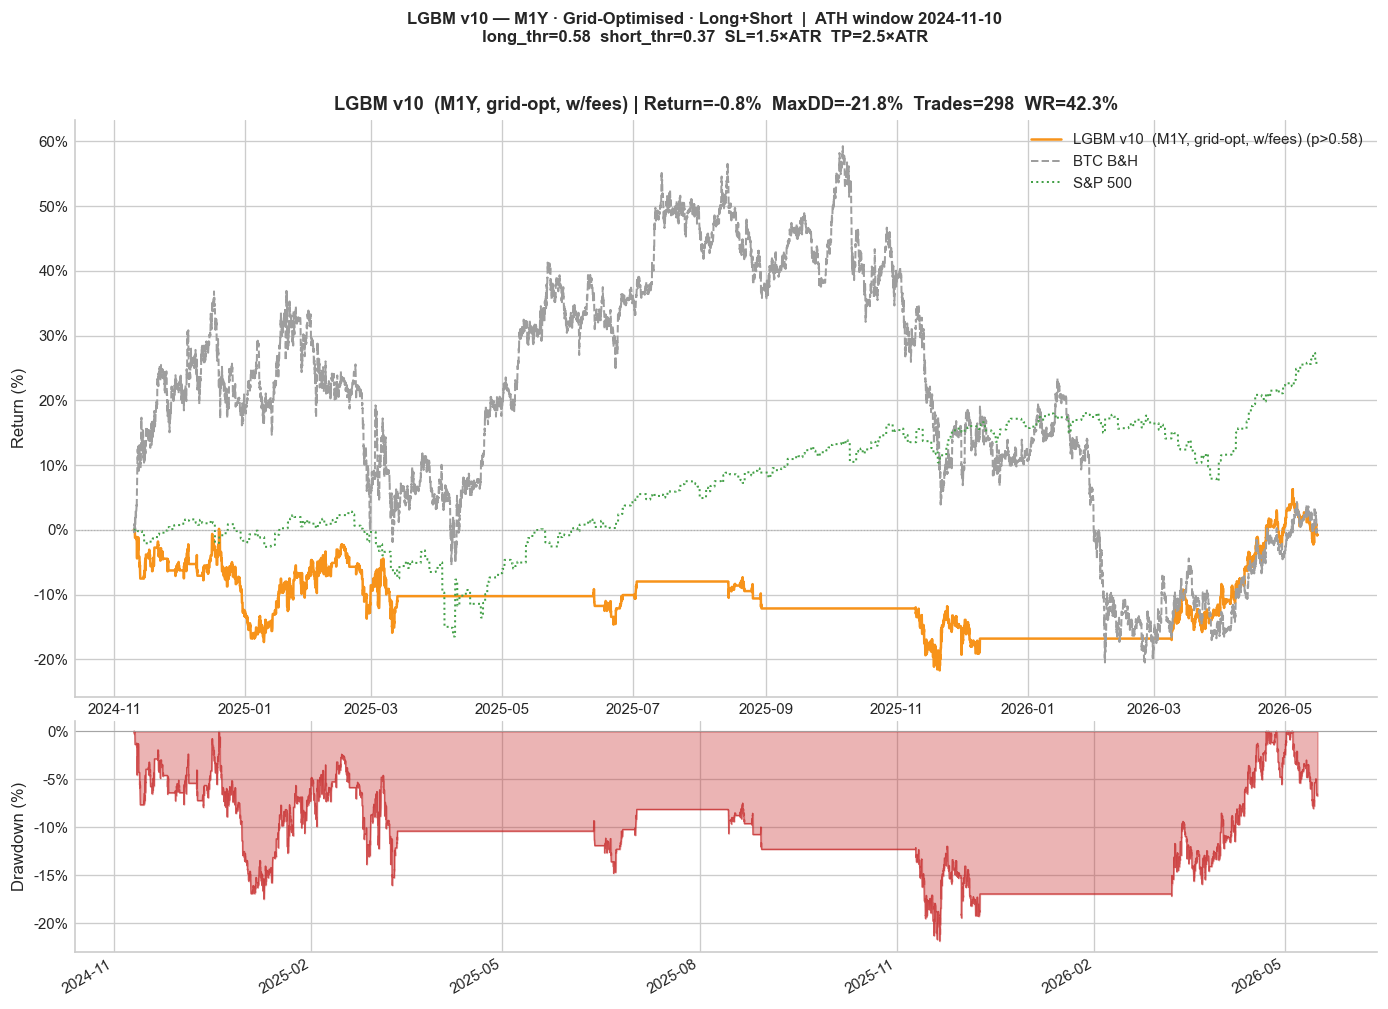

In [17]:
from hmats.viz.plots import plot_equity_drawdown, save_fig

tdf_ath = (tdf_fees[tdf_fees['direction'].notna()].copy()
           if len(tdf_fees) > 0 else pd.DataFrame())

fig = plot_equity_drawdown(
    oos_index_ath, eq_fees_ath, tdf_ath,
    bh_pct=bh_pct, sp500_pct=sp500_pct,
    label=f'LGBM v10  (M1Y, grid-opt, w/fees)',
    threshold=BEST_PARAMS['long_threshold'], color=ACCENT,
)
fig.suptitle(
    f'LGBM v10 — M1Y · Grid-Optimised · Long+Short  |  ATH window {ATH_START.date()}'
    f'\nlong_thr={BEST_PARAMS["long_threshold"]}  short_thr={BEST_PARAMS["short_threshold"]}'
    f'  SL={BEST_PARAMS["sl_atr_mult"]}×ATR  TP={BEST_PARAMS["tp_atr_mult"]}×ATR',
    fontsize=10, fontweight='bold',
)
save_fig(fig, ARTS_DIR / '01_equity_drawdown.png')
plt.show()


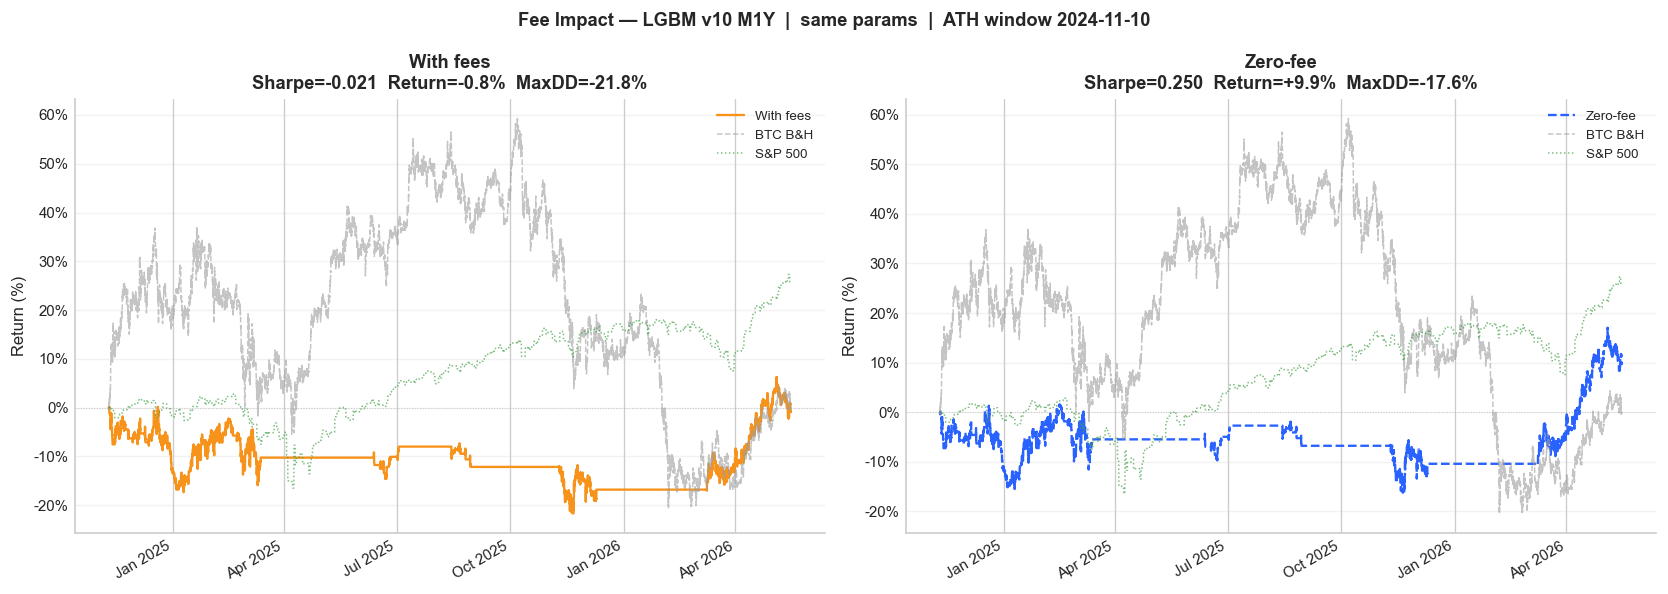

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (lbl, eq, color, ls) in zip(axes, [
    ('With fees',   eq_fees_ath, ACCENT, '-'),
    ('Zero-fee',    eq_0fee_ath, BLUE,   '--'),
]):
    ax.plot(oos_index_ath, (eq-1)*100, color=color, lw=1.4, ls=ls, label=lbl)
    ax.plot(oos_index_ath, bh_pct,     color=GREY,  lw=0.9, ls='--', alpha=0.6, label='BTC B&H')
    if sp500_pct is not None:
        ax.plot(oos_index_ath, sp500_pct.values, color='#43A047', lw=0.9, ls=':', alpha=0.7, label='S&P 500')
    ax.axhline(0, color=GREY, lw=0.6, ls=':', alpha=0.5)
    sh = _sharpe(eq); ret = eq[-1]-1; dd = _maxdd(eq)
    ax.set_title(f'{lbl}\nSharpe={sh:.3f}  Return={ret:+.1%}  MaxDD={dd:.1%}', fontweight='bold')
    ax.set_ylabel('Return (%)'); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(f'Fee Impact — LGBM v10 M1Y  |  same params  |  ATH window {ATH_START.date()}',
             fontweight='bold', fontsize=11)
fig.tight_layout()
save_fig(fig, ARTS_DIR / '02_fee_comparison.png')
plt.show()


PHASE 4 — MONTHLY RETURN ANALYSIS
Monthly stats (w/ fees, full OOS):
  Positive months : 10 / 29
  Avg monthly ret : +1.34%
  Median monthly  : +0.00%
  Best month      : +30.51%  (Mar 2024)
  Worst month     : -8.20%  (Dec 2024)
  Monthly std dev : 7.39%

open_time
2024-01-31    0.0000
2024-02-29    4.0542
2024-03-31   30.5063
2024-04-30   -8.0051
2024-05-31   -3.0646
2024-06-30   -5.0081
2024-07-31    9.2009
2024-08-31   -0.1584
2024-09-30    0.0000
2024-10-31    2.8628
2024-11-30    1.3277
2024-12-31   -8.1959
2025-01-31    9.8504
2025-02-28   -3.9864
2025-03-31   -1.8346
2025-04-30    0.0000
2025-05-31    0.0000
2025-06-30    0.1931
2025-07-31    2.3269
2025-08-31   -4.5242
2025-09-30    0.0000
2025-10-31    0.0000
2025-11-30   -4.2927
2025-12-31   -1.0547
2026-01-31    0.0000
2026-02-28    0.0000
2026-03-31    7.7104
2026-04-30   12.3050
2026-05-31   -1.4282
Freq: ME


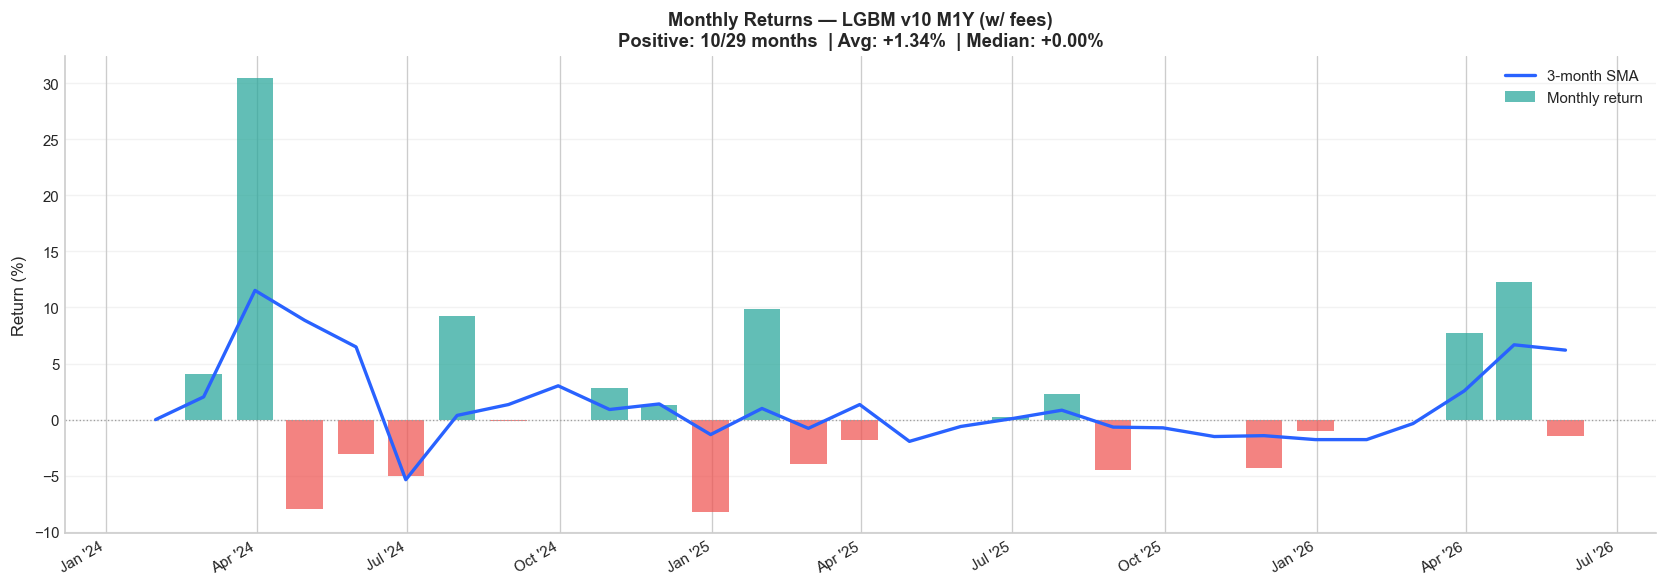

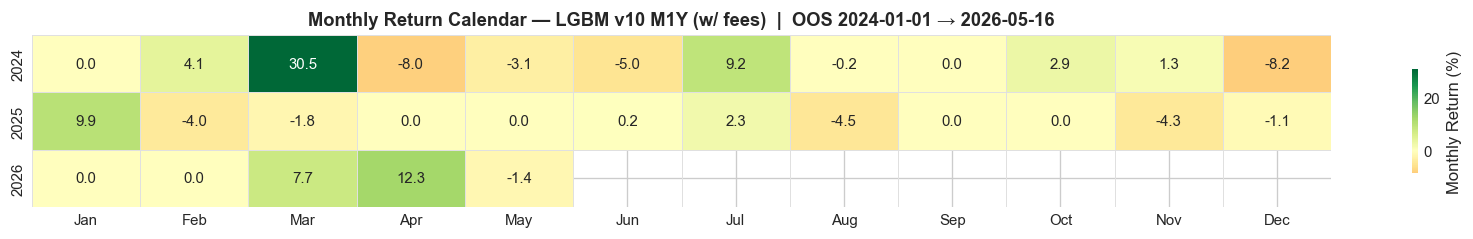

In [19]:
print('='*60)
print('PHASE 4 — MONTHLY RETURN ANALYSIS')
print('='*60)

# Monthly returns from full OOS equity (not ATH-rebased, to capture all months)
eq_full_series = pd.Series(eq_fees, index=oos_df.index)
monthly_eq     = eq_full_series.resample('ME').last()
monthly_ret    = monthly_eq.pct_change().fillna(0) * 100     # % per month
sma3           = monthly_ret.rolling(3, min_periods=1).mean()

print(f'Monthly stats (w/ fees, full OOS):')
print(f'  Positive months : {(monthly_ret>0).sum()} / {len(monthly_ret)}')
print(f'  Avg monthly ret : {monthly_ret.mean():+.2f}%')
print(f'  Median monthly  : {monthly_ret.median():+.2f}%')
print(f'  Best month      : {monthly_ret.max():+.2f}%  ({monthly_ret.idxmax().strftime("%b %Y")})')
print(f'  Worst month     : {monthly_ret.min():+.2f}%  ({monthly_ret.idxmin().strftime("%b %Y")})')
print(f'  Monthly std dev : {monthly_ret.std():.2f}%')
print()
print(monthly_ret.to_string())

# ── Chart A: bar chart + SMA-3 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
colors = [GREEN if r >= 0 else RED for r in monthly_ret.values]
ax.bar(monthly_ret.index, monthly_ret.values, color=colors, alpha=0.72,
       width=22, label='Monthly return')
ax.plot(monthly_ret.index, sma3.values, color=BLUE, lw=2.0,
        label='3-month SMA', zorder=5)
ax.axhline(0, color=GREY, lw=0.8, ls=':')
ax.set_ylabel('Return (%)')
ax.set_xlabel('')
ax.set_title(f'Monthly Returns — LGBM v10 M1Y (w/ fees)\n'
             f'Positive: {(monthly_ret>0).sum()}/{len(monthly_ret)} months  '
             f'| Avg: {monthly_ret.mean():+.2f}%  | Median: {monthly_ret.median():+.2f}%',
             fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.tight_layout()
save_fig(fig, ARTS_DIR / '03_monthly_returns.png')
plt.show()

# ── Chart B: calendar heatmap ─────────────────────────────────────────────────
cal_df = monthly_ret.to_frame('ret').copy()
cal_df['year']  = cal_df.index.year
cal_df['month'] = cal_df.index.month
pivot = cal_df.pivot(index='year', columns='month', values='ret')
pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]

fig2, ax2 = plt.subplots(figsize=(14, max(2, len(pivot)*0.7)))
sns.heatmap(pivot, ax=ax2, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#e0e0e0',
            cbar_kws={'label': 'Monthly Return (%)', 'shrink': 0.6},
            annot_kws={'size': 9})
ax2.set_title(f'Monthly Return Calendar — LGBM v10 M1Y (w/ fees)  |  '
              f'OOS {OOS_START.date()} → {oos_df.index[-1].date()}',
              fontweight='bold')
ax2.set_xlabel(''); ax2.set_ylabel('')
fig2.tight_layout()
save_fig(fig2, ARTS_DIR / '04_monthly_heatmap.png')
plt.show()


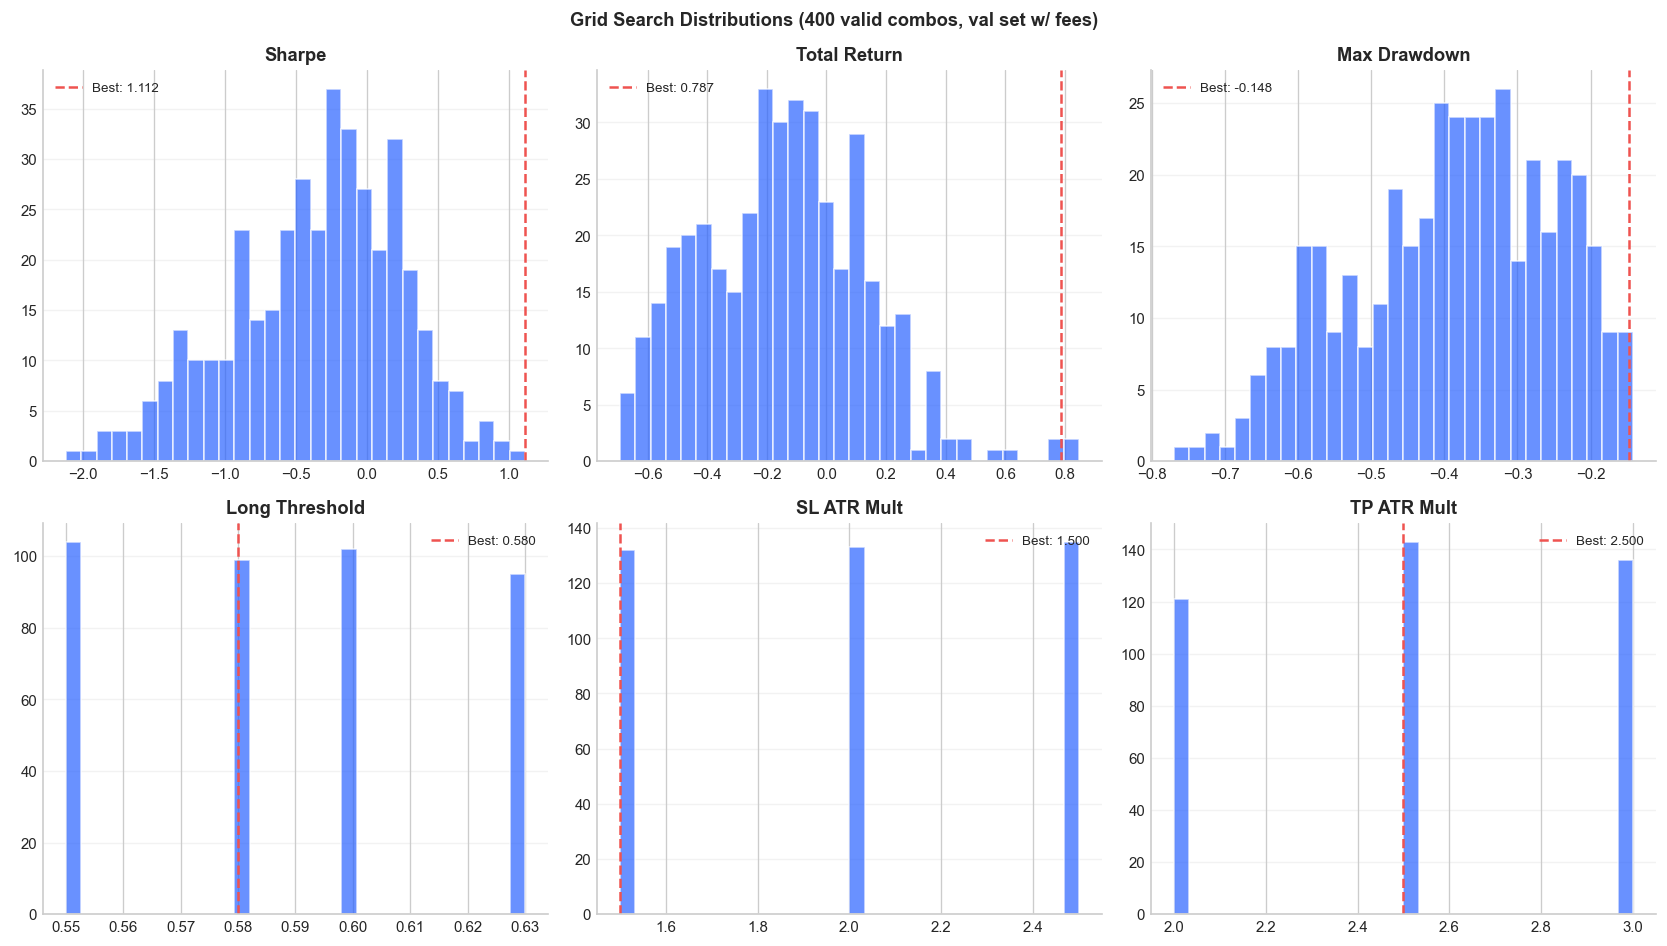

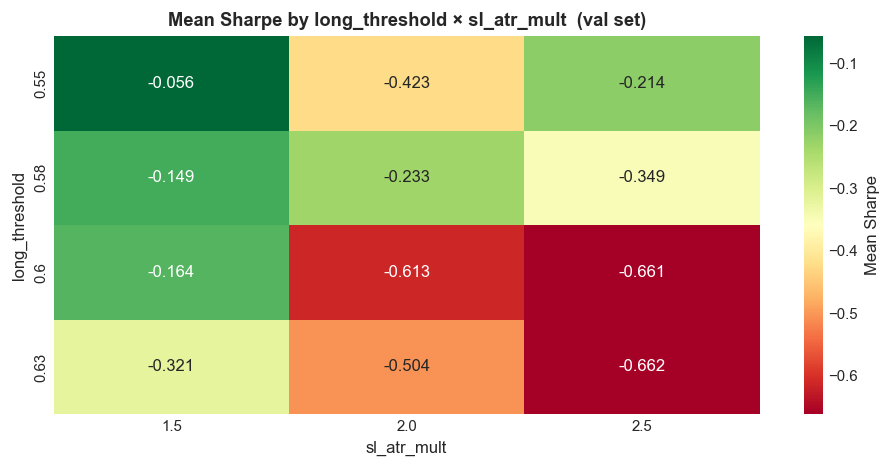

In [20]:
if len(grid_df) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()

    for ax, col in zip(axes, ['sharpe', 'total_ret', 'maxdd',
                               'long_threshold', 'sl_atr_mult', 'tp_atr_mult']):
        data = grid_df[col].dropna()
        label_map = {'total_ret': 'Total Return', 'maxdd': 'Max Drawdown',
                     'sharpe': 'Sharpe', 'long_threshold': 'Long Threshold',
                     'sl_atr_mult': 'SL ATR Mult', 'tp_atr_mult': 'TP ATR Mult'}
        ax.hist(data, bins=30, color=BLUE, alpha=0.7, edgecolor='white')
        best_val = grid_df.iloc[0][col]
        ax.axvline(best_val, color=RED, lw=1.5, ls='--',
                   label=f'Best: {best_val:.3f}')
        ax.set_title(label_map.get(col, col), fontweight='bold')
        ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)

    fig.suptitle(f'Grid Search Distributions ({len(grid_df):,} valid combos, val set w/ fees)',
                 fontweight='bold', fontsize=11)
    fig.tight_layout()
    save_fig(fig, ARTS_DIR / '05_grid_distributions.png')
    plt.show()

    # Heatmap: long_thr × sl_atr_mult (avg Sharpe)
    pivot_gs = grid_df.pivot_table(index='long_threshold', columns='sl_atr_mult',
                                   values='sharpe', aggfunc='mean')
    fig3, ax3 = plt.subplots(figsize=(8, 4))
    sns.heatmap(pivot_gs, ax=ax3, cmap='RdYlGn', annot=True, fmt='.3f',
                cbar_kws={'label': 'Mean Sharpe'})
    ax3.set_title('Mean Sharpe by long_threshold × sl_atr_mult  (val set)',
                  fontweight='bold')
    fig3.tight_layout()
    save_fig(fig3, ARTS_DIR / '06_grid_heatmap.png')
    plt.show()


In [21]:
def _bt_metrics(eq, tdf, label):
    wr = float((tdf['net']>0).mean()) if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum())  if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum()) if len(tdf) else 0
    return {
        'label': label, 'n_trades': len(tdf),
        'n_long': n_l, 'n_short': n_s,
        'win_rate': round(wr, 4),
        'total_ret': round(float(eq[-1]-1), 4),
        'sharpe': round(_sharpe(eq), 4),
        'maxdd': round(_maxdd(eq), 4),
        # ATH-window subset
        'ath_total_ret': round(float(_rebase(eq)[-1]-1), 4),
        'ath_sharpe': round(_sharpe(_rebase(eq)), 4),
        'ath_maxdd': round(_maxdd(_rebase(eq)), 4),
    }

results = {
    'notebook': '02_lgbm_omni_0fee_v10',
    'version': 'v10',
    'created': pd.Timestamp.now().isoformat(),
    'scheme': 'M1Y (1-year sliding)',
    'oos_period': f'{OOS_START.date()} → {oos_df.index[-1].date()}',
    'ath_window': f'{ATH_START.date()} → {oos_ath.index[-1].date()}',
    'grid_val_window': f'{GRID_VAL_START.date()} → {GRID_VAL_END.date()}',
    'n_random_search': N_RANDOM_SEARCH,
    'n_valid_combos': len(grid_df),
    'oos_auc': round(float(auc_oos), 4),
    'grid_val_auc': round(float(auc_gv), 4),
    'selected_features': SELECTED_FEATURES,
    'best_params': BEST_PARAMS,
    'fees': {
        'maker': MAKER_FEE, 'spot_taker': SPOT_TAKER_FEE,
        'futures_taker': FUTURES_TAKER_FEE, 'buffer': BUFFER,
        'short_funding_h': SHORT_FUNDING_H,
    },
    'backtest_wfees': _bt_metrics(eq_fees, tdf_fees, 'w_fees'),
    'backtest_0fee':  _bt_metrics(eq_0fee, tdf_0fee, '0_fee'),
    'monthly_returns': {
        'mean_pct': round(float(monthly_ret.mean()), 3),
        'median_pct': round(float(monthly_ret.median()), 3),
        'std_pct': round(float(monthly_ret.std()), 3),
        'positive_months': int((monthly_ret>0).sum()),
        'total_months': int(len(monthly_ret)),
        'best_month': {'date': str(monthly_ret.idxmax().date()),
                       'ret': round(float(monthly_ret.max()), 3)},
        'worst_month': {'date': str(monthly_ret.idxmin().date()),
                        'ret': round(float(monthly_ret.min()), 3)},
    }
}

out_path = ARTS_DIR / 'results.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved → {out_path}')
print(json.dumps(results, indent=2)[:1200])


Saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v10/results.json
{
  "notebook": "02_lgbm_omni_0fee_v10",
  "version": "v10",
  "created": "2026-05-31T18:50:08.528476",
  "scheme": "M1Y (1-year sliding)",
  "oos_period": "2024-01-01 \u2192 2026-05-16",
  "ath_window": "2024-11-10 \u2192 2026-05-16",
  "grid_val_window": "2022-01-01 \u2192 2023-12-31",
  "n_random_search": 400,
  "n_valid_combos": 400,
  "oos_auc": 0.537,
  "grid_val_auc": 0.5644,
  "selected_features": [
    "close_vs_true_vwap",
    "stoch_k_14",
    "ret_2h",
    "rsi_divergence",
    "close_vs_sma_7",
    "bear_streak",
    "close_vs_s1",
    "macd_hist_5_13",
    "hurst_24h",
    "ad_z_48h",
    "ret_3h"
  ],
  "best_params": {
    "long_threshold": 0.58,
    "short_threshold": 0.37,
    "entry_atr_mult": 0.3,
    "sl_atr_mult": 1.5,
    "tp_atr_mult": 2.5,
    "min_sl": 0.01,
    "min_hold": 8,
    "max_hold": 48,
    "cooldown": 3
  },
  "fees": {
    "maker"